In [1]:
# Profile and CPU policy: keep this cell before numerical-library imports.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                 "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

PROFILE = os.environ.get("TINYMML_PROFILE", "reduced").lower()
CUSTOM_CONFIG = {
    "train_samples": 250, "test_samples": 60, "epochs": 150,
    "batch_size": 32, "inference_repeats": 10,
}
PROFILE_CONFIGS = {
    "reduced": {"train_samples": 250, "test_samples": 60, "epochs": 150,
                "batch_size": 32, "inference_repeats": 10},
    "full": {"train_samples": 353, "test_samples": 89, "epochs": 300,
             "batch_size": 32, "inference_repeats": 20},
    "custom": CUSTOM_CONFIG,
}

def resolve_config(profile):
    if profile not in PROFILE_CONFIGS:
        raise ValueError("TINYMML_PROFILE must be 'reduced', 'full', or 'custom'")
    config = dict(PROFILE_CONFIGS[profile])
    limits = {"train_samples": 353, "test_samples": 89}
    for key, maximum in limits.items():
        if not isinstance(config[key], int) or not 1 <= config[key] <= maximum:
            raise ValueError(f"{key} must be an integer between 1 and {maximum}")
    for key in ("epochs", "batch_size", "inference_repeats"):
        if not isinstance(config[key], int) or config[key] <= 0:
            raise ValueError(f"{key} must be a positive integer")
    return config

for profile_name in PROFILE_CONFIGS:
    resolve_config(profile_name)
CONFIG = {**resolve_config(PROFILE), "seed": 42, "learning_rate": 1e-2, "weight_decay": 1e-3}
CONFIG

{'train_samples': 250,
 'test_samples': 60,
 'epochs': 150,
 'batch_size': 32,
 'inference_repeats': 10,
 'seed': 42,
 'learning_rate': 0.01,
 'weight_decay': 0.001}

# Diabetes regression MLP: TinyMML vs Keras

Explore clinical features, train equivalent dropout MLP regressors, and compare prediction quality and CPU performance. Scaling is learned from training data only.

In [2]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

THREAD_LIMITER = threadpool_limits(limits=1)
import tensorflow as tf
import keras
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"]); tt.manual_seed(CONFIG["seed"]); keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

def subset_indices(length, count, seed):
    if count == length: return np.arange(length)
    return np.random.default_rng(seed).choice(length, size=count, replace=False)

def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter(); predict(); durations.append(perf_counter() - started)
    median = float(np.median(durations))
    return 1_000 * median, samples / median

def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])

environment = {"profile": PROFILE, "platform": platform.platform(), "machine": platform.machine(),
               "logical CPUs": os.cpu_count(), "Python": platform.python_version(),
               "NumPy": np.__version__, "TensorFlow": tf.__version__, "Keras": keras.__version__,
               "scikit-learn": version("scikit-learn"), "TinyTensor CUDA": tt.cuda_available()}
display(Markdown("## Environment and active profile\n" + "\n".join(f"- **{k}:** {v}" for k, v in environment.items())))
display(CONFIG)

## Environment and active profile
- **profile:** reduced
- **platform:** macOS-26.5.1-arm64-arm-64bit-Mach-O
- **machine:** arm64
- **logical CPUs:** 8
- **Python:** 3.13.14
- **NumPy:** 2.4.3
- **TensorFlow:** 2.21.0
- **Keras:** 3.15.0
- **scikit-learn:** 1.9.0
- **TinyTensor CUDA:** False

{'train_samples': 250,
 'test_samples': 60,
 'epochs': 150,
 'batch_size': 32,
 'inference_repeats': 10,
 'seed': 42,
 'learning_rate': 0.01,
 'weight_decay': 0.001}

## Load and explore the Diabetes dataset

Samples/features: 442 / 10
Selected train/test: 250 / 60
Missing values: 0
Target range and mean: 25 to 346; mean=152.1


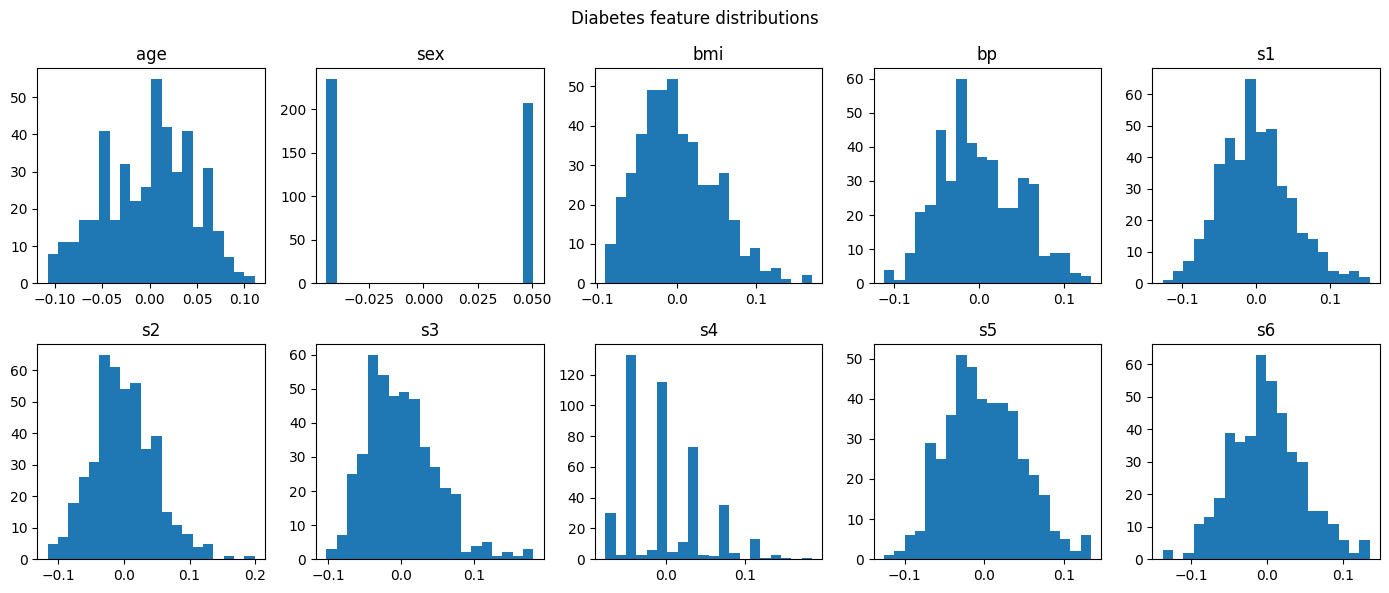

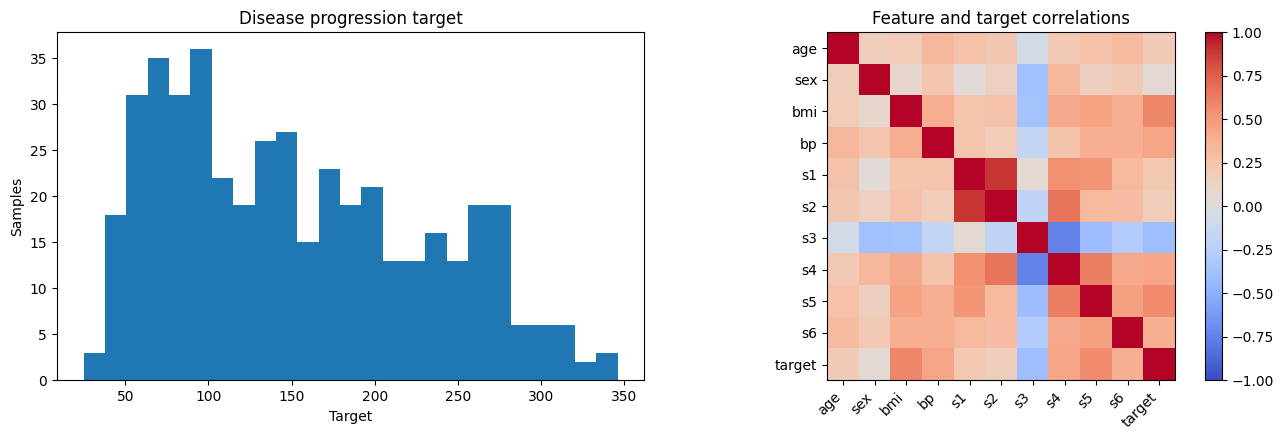

In [3]:
dataset = load_diabetes()
x_all, y_all = dataset.data.astype(np.float32), dataset.target.astype(np.float32)
x_pool_train, x_pool_test, y_pool_train, y_pool_test = train_test_split(
    x_all, y_all, test_size=0.2, random_state=CONFIG["seed"],
)
train_indices = subset_indices(len(x_pool_train), CONFIG["train_samples"], CONFIG["seed"])
test_indices = subset_indices(len(x_pool_test), CONFIG["test_samples"], CONFIG["seed"] + 1)
x_train, y_train = x_pool_train[train_indices], y_pool_train[train_indices]
x_test, y_test = x_pool_test[test_indices], y_pool_test[test_indices]

missing_values = int(np.isnan(x_all).sum() + np.isnan(y_all).sum())
print(f"Samples/features: {x_all.shape[0]} / {x_all.shape[1]}")
print(f"Selected train/test: {x_train.shape[0]} / {x_test.shape[0]}")
print(f"Missing values: {missing_values}")
print(f"Target range and mean: {y_all.min():.0f} to {y_all.max():.0f}; mean={y_all.mean():.1f}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for feature_index, axis in enumerate(axes.flat):
    axis.hist(x_all[:, feature_index], bins=20)
    axis.set_title(dataset.feature_names[feature_index])
plt.suptitle("Diabetes feature distributions")
plt.tight_layout(); plt.show()

correlations = np.corrcoef(np.column_stack([x_all, y_all]), rowvar=False)
labels = [*dataset.feature_names, "target"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_all, bins=25)
axes[0].set(title="Disease progression target", xlabel="Target", ylabel="Samples")
image = axes[1].imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axes[1].set_yticks(range(len(labels)), labels)
axes[1].set_title("Feature and target correlations")
fig.colorbar(image, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

x_scaler, y_scaler = StandardScaler(), StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train).astype(np.float32)
x_test_scaled = x_scaler.transform(x_test).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train[:, None]).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test[:, None]).astype(np.float32)
assert np.allclose(x_train_scaled.mean(0), 0.0, atol=1e-5)
assert np.allclose(y_train_scaled.mean(), 0.0, atol=1e-5)

## Matched regression MLPs

Both models use `10 → 64 → ReLU → Dropout(0.1) → 32 → ReLU → 1`, He initialization, Adam at `1e-2` with `1e-3` weight decay, and MSE.

In [4]:
tt.manual_seed(CONFIG["seed"])
tiny_model = tm.Model([
    tm.Linear(64, init="he"), tm.ReLU(), tm.Dropout(0.1),
    tm.Linear(32, init="he"), tm.ReLU(), tm.Linear(1),
])
tiny_model.build(list(x_train_scaled.shape))
tiny_optimizer = tm.Adam(tiny_model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
tiny_loss = tm.MSELoss()

keras.utils.set_random_seed(CONFIG["seed"])
keras_model = keras.Sequential([
    keras.layers.Input(shape=(10,)),
    keras.layers.Dense(64, kernel_initializer="he_normal"), keras.layers.ReLU(), keras.layers.Dropout(0.1),
    keras.layers.Dense(32, kernel_initializer="he_normal"), keras.layers.ReLU(), keras.layers.Dense(1),
])
keras_model.compile(optimizer=keras.optimizers.Adam(CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]), loss="mse")

model_info = [
    {"library": "TinyMML", "parameters": sum(p.size() for p in tiny_model.parameters()),
     "steps/epoch": int(np.ceil(len(x_train_scaled) / CONFIG["batch_size"]))},
    {"library": "Keras", "parameters": keras_model.count_params(),
     "steps/epoch": int(np.ceil(len(x_train_scaled) / CONFIG["batch_size"]))},
]
display(Markdown(markdown_table(model_info, ["library", "parameters", "steps/epoch"])))

| library | parameters | steps/epoch |
| --- | --- | --- |
| TinyMML | 2817 | 8 |
| Keras | 2817 | 8 |

In [5]:
np.random.seed(CONFIG["seed"]); tt.manual_seed(CONFIG["seed"])
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_scaled, y_train_scaled, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer, loss_fn=tiny_loss, verbose=False,
)
tiny_train_seconds = perf_counter() - started
keras.utils.set_random_seed(CONFIG["seed"])
started = perf_counter()
keras_history = keras_model.fit(x_train_scaled, y_train_scaled, epochs=CONFIG["epochs"],
                                batch_size=CONFIG["batch_size"], shuffle=True, verbose=0)
keras_train_seconds = perf_counter() - started

tiny_scaled_predictions = tiny_model.predict(x_test_scaled, batch_size=CONFIG["batch_size"])
keras_scaled_predictions = keras_model.predict(x_test_scaled, batch_size=CONFIG["batch_size"], verbose=0)
tiny_predictions = y_scaler.inverse_transform(tiny_scaled_predictions).reshape(-1)
keras_predictions = y_scaler.inverse_transform(keras_scaled_predictions).reshape(-1)
baseline_predictions = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(x_test_scaled, batch_size=CONFIG["batch_size"]), len(x_test_scaled), CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(x_test_scaled, batch_size=CONFIG["batch_size"], verbose=0), len(x_test_scaled), CONFIG["inference_repeats"],
)

def result_row(library, predictions, training_seconds, latency, throughput):
    return {"library": library, "MAE": f"{mean_absolute_error(y_test, predictions):.2f}",
            "RMSE": f"{root_mean_squared_error(y_test, predictions):.2f}",
            "R2": f"{r2_score(y_test, predictions):.3f}", "training s": f"{training_seconds:.2f}",
            "inference ms": f"{latency:.3f}", "samples/s": f"{throughput:.1f}"}

results = [result_row("TinyMML", tiny_predictions, tiny_train_seconds, tiny_latency, tiny_throughput),
           result_row("Keras", keras_predictions, keras_train_seconds, keras_latency, keras_throughput)]
display(Markdown(f"## Reduced-profile results\nTrain-mean MAE baseline: **{baseline_mae:.2f}**\n\n" +
                 markdown_table(results, list(results[0]))))

## Reduced-profile results
Train-mean MAE baseline: **66.26**

| library | MAE | RMSE | R2 | training s | inference ms | samples/s |
| --- | --- | --- | --- | --- | --- | --- |
| TinyMML | 49.56 | 62.54 | 0.311 | 1.99 | 0.502 | 119601.2 |
| Keras | 49.88 | 61.88 | 0.326 | 3.19 | 30.810 | 1947.4 |

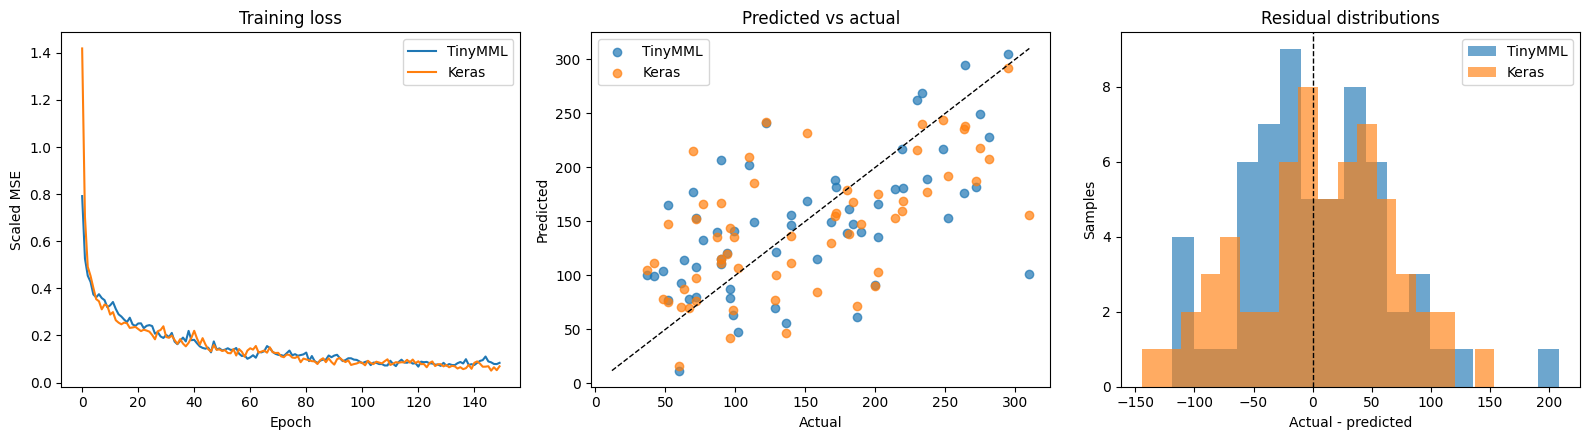

### Largest test-set prediction errors
| row | actual | TinyMML | Keras | max abs error |
| --- | --- | --- | --- | --- |
| 43 | 310.0 | 101.4 | 156.2 | 208.6 |
| 36 | 70.0 | 177.4 | 214.6 | 144.6 |
| 55 | 187.0 | 61.8 | 71.6 | 125.2 |
| 56 | 122.0 | 240.7 | 242.1 | 120.1 |
| 12 | 90.0 | 206.4 | 166.5 | 116.4 |
| 19 | 52.0 | 164.9 | 147.5 | 112.9 |
| 58 | 200.0 | 90.9 | 90.0 | 110.0 |
| 11 | 110.0 | 202.5 | 209.6 | 99.6 |

DIABETES NOTEBOOK ACCEPTANCE PASSED


In [6]:
tiny_residuals, keras_residuals = y_test - tiny_predictions, y_test - keras_predictions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(tiny_history["loss"], label="TinyMML")
axes[0].plot(keras_history.history["loss"], label="Keras")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Scaled MSE"); axes[0].legend()
limits = [min(y_test.min(), tiny_predictions.min(), keras_predictions.min()),
          max(y_test.max(), tiny_predictions.max(), keras_predictions.max())]
axes[1].scatter(y_test, tiny_predictions, alpha=0.7, label="TinyMML")
axes[1].scatter(y_test, keras_predictions, alpha=0.7, label="Keras")
axes[1].plot(limits, limits, "k--", linewidth=1)
axes[1].set(title="Predicted vs actual", xlabel="Actual", ylabel="Predicted"); axes[1].legend()
axes[2].hist(tiny_residuals, bins=18, alpha=0.65, label="TinyMML")
axes[2].hist(keras_residuals, bins=18, alpha=0.65, label="Keras")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set(title="Residual distributions", xlabel="Actual - predicted", ylabel="Samples"); axes[2].legend()
plt.tight_layout(); plt.show()

combined_error = np.maximum(np.abs(tiny_residuals), np.abs(keras_residuals))
worst_indices = np.argsort(combined_error)[-8:][::-1]
worst_rows = [{"row": int(index), "actual": f"{y_test[index]:.1f}",
               "TinyMML": f"{tiny_predictions[index]:.1f}", "Keras": f"{keras_predictions[index]:.1f}",
               "max abs error": f"{combined_error[index]:.1f}"} for index in worst_indices]
display(Markdown("### Largest test-set prediction errors\n" + markdown_table(worst_rows, list(worst_rows[0]))))

tiny_mae, keras_mae = mean_absolute_error(y_test, tiny_predictions), mean_absolute_error(y_test, keras_predictions)
tiny_r2, keras_r2 = r2_score(y_test, tiny_predictions), r2_score(y_test, keras_predictions)
assert np.isfinite(tiny_history["loss"]).all() and np.isfinite(keras_history.history["loss"]).all()
assert tiny_history["loss"][-1] < tiny_history["loss"][0]
assert keras_history.history["loss"][-1] < keras_history.history["loss"][0]
assert np.isfinite(tiny_predictions).all() and np.isfinite(keras_predictions).all()
assert tiny_mae < baseline_mae, f"TinyMML MAE {tiny_mae:.2f} did not beat baseline {baseline_mae:.2f}"
assert keras_mae < baseline_mae, f"Keras MAE {keras_mae:.2f} did not beat baseline {baseline_mae:.2f}"
assert tiny_r2 > 0.0, f"TinyMML R2 must be positive, got {tiny_r2:.3f}"
assert keras_r2 > 0.0, f"Keras R2 must be positive, got {keras_r2:.3f}"
print("DIABETES NOTEBOOK ACCEPTANCE PASSED")